# Autoresearch Experiment Analysis

Analysis of autonomous hyperparameter tuning results from `results.tsv`.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the TSV (tab-separated, 5 columns: commit, action_ce, memory_gb, status, description)
df = pd.read_csv("results.tsv", sep="\t")
df["action_ce"] = pd.to_numeric(df["action_ce"], errors="coerce")
df["memory_gb"] = pd.to_numeric(df["memory_gb"], errors="coerce")
df["status"] = df["status"].str.strip().str.upper()

print(f"Total experiments: {len(df)}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Total experiments: 81
Columns: ['commit', 'score', 'action_ce', 'latency_ms', 'memory_gb', 'status', 'description']


,commit,score,action_ce,latency_ms,memory_gb,status,description
0,cd3b097,-5.417830,2.328940,1235.6,1.6,KEEP,baseline SmolVLM2-500M frozen backbone + 4-lay...
1,d9180bd,-1.386515,1.370719,6.3,1.2,KEEP,"lightweight CNN encoder, 6 layers, batch 32"
2,e14a26f,-1.402880,1.386112,6.7,1.5,DISCARD,"depth 8: more params but fewer steps, net worse"
3,a64dde4,-1.549808,1.526518,9.3,1.7,DISCARD,"8 frames stride 2: too expensive, fewer steps"
4,d7f57c9,-1.519761,1.505154,5.8,1.2,DISCARD,"LR 1e-3 too high, overshoots"
5,60116f0,-1.407867,1.391407,6.6,1.2,DISCARD,LR 5e-4 slightly worse than 3e-4
6,bb5383f,-1.454005,1.439097,6.0,1.2,DISCARD,chunk_size=1 worse: less training signal
7,f98db9c,-1.677037,1.379451,119.0,1.2,DISCARD,torch.compile: eval recompilation kills latency
8,76cbaad,-1.394825,1.369009,10.3,1.2,DISCARD,"2x2 tokens: lost spatial detail, latency up"
9,0c45a60,-1.367974,1.352051,6.4,1.2,KEEP,GroupNorm in CNN encoder


In [11]:
counts = df["status"].value_counts()
print("Experiment outcomes:")
print(counts.to_string())

n_keep = counts.get("KEEP", 0)
n_discard = counts.get("DISCARD", 0)
n_crash = counts.get("CRASH", 0)
n_decided = n_keep + n_discard
if n_decided > 0:
    print(f"\nKeep rate: {n_keep}/{n_decided} = {n_keep / n_decided:.1%}")

Experiment outcomes:
status
DISCARD    62
KEEP       19

Keep rate: 19/81 = 23.5%


In [12]:
# Show all KEPT experiments (the improvements that stuck)
kept = df[df["status"] == "KEEP"].copy()
print(f"KEPT experiments ({len(kept)} total):\n")
for i, row in kept.iterrows():
    bpb = row["action_ce"]
    desc = row["description"]
    print(f"  #{i:3d}  action_ce={bpb:.6f}  mem={row['memory_gb']:.1f}GB  {desc}")

KEPT experiments (19 total):

  #  0  action_ce=2.328940  mem=1.6GB  baseline SmolVLM2-500M frozen backbone + 4-layer action decoder
  #  1  action_ce=1.370719  mem=1.2GB  lightweight CNN encoder, 6 layers, batch 32
  #  9  action_ce=1.352051  mem=1.2GB  GroupNorm in CNN encoder
  # 10  action_ce=1.329754  mem=1.2GB  past_action_chunk_size=4, more temporal conditioning
  # 11  action_ce=1.315298  mem=1.2GB  SwiGLU MLP replaces GeLU MLP
  # 12  action_ce=1.302238  mem=1.2GB  learnable temporal position per frame
  # 16  action_ce=1.198648  mem=0.9GB  batch 16: 2x updates, big CE improvement
  # 18  action_ce=1.191100  mem=0.9GB  weight_decay 0.01: less regularization helps
  # 19  action_ce=1.139817  mem=0.9GB  warmdown 0.30: more time at peak LR, big CE gain
  # 25  action_ce=1.129180  mem=0.8GB  depth 4 / 512d: more steps, better CE
  # 32  action_ce=1.112437  mem=0.8GB  LR 2e-4: scaled for batch 16, best CE yet
  # 33  action_ce=1.108180  mem=0.8GB  LR 1.5e-4: lower LR keeps improvin

## Val BPB Over Time

Track how the best (kept) action_ce evolves as experiments progress. The running minimum shows the "frontier" -- the best result achieved so far.

NameError: name 'best' is not defined

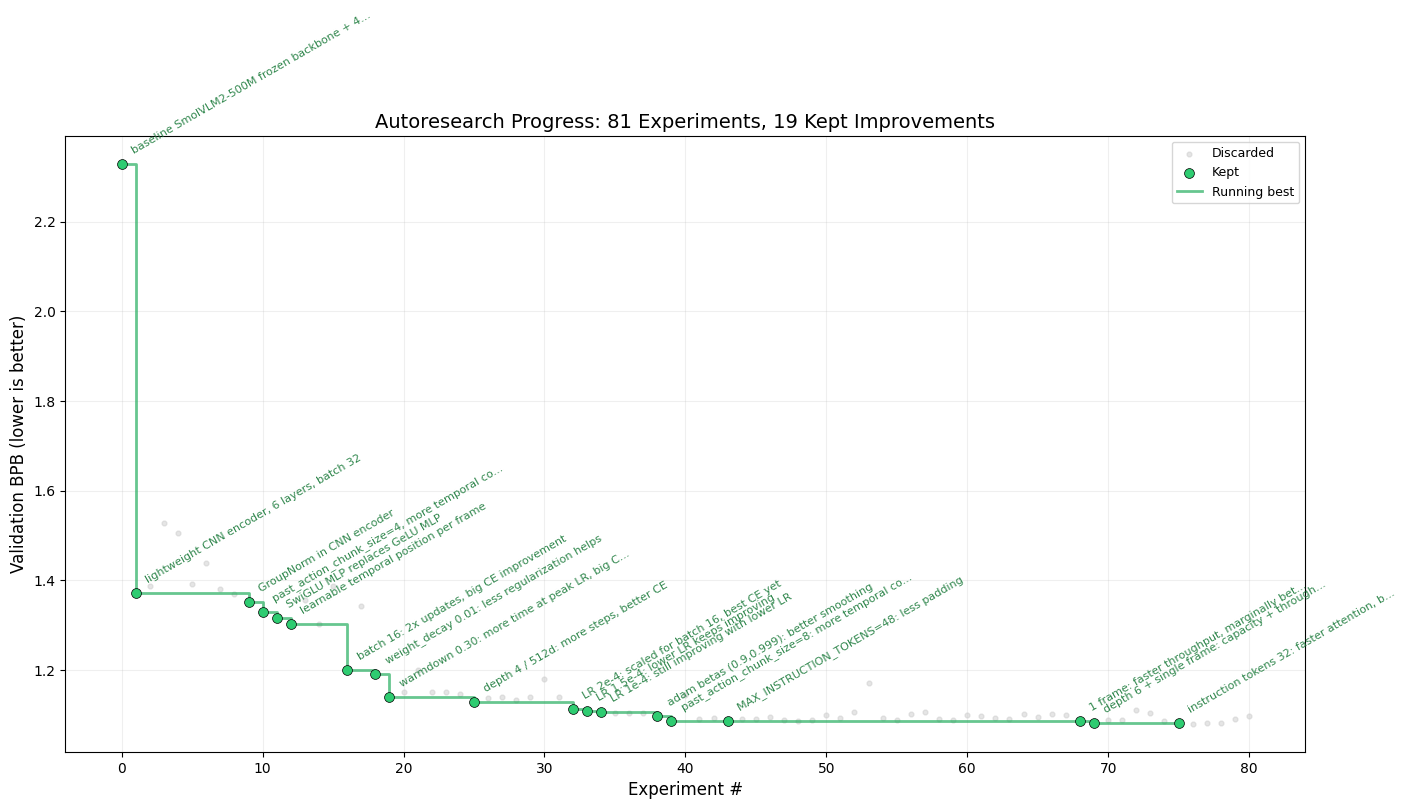

In [ ]:
fig, ax = plt.subplots(figsize=(16, 8))

# Filter out crashes for plotting
valid = df[df["status"] != "CRASH"].copy()
valid = valid.reset_index(drop=True)

baseline_bpb = valid.loc[0, "action_ce"]

# Only plot points at or below baseline (the interesting region)
below = valid[valid["action_ce"] <= baseline_bpb + 0.0005]

# Plot discarded as faint background dots
disc = below[below["status"] == "DISCARD"]
ax.scatter(disc.index, disc["action_ce"],
           c="#cccccc", s=12, alpha=0.5, zorder=2, label="Discarded")

# Plot kept experiments as prominent green dots
kept_v = below[below["status"] == "KEEP"]
ax.scatter(kept_v.index, kept_v["action_ce"],
           c="#2ecc71", s=50, zorder=4, label="Kept", edgecolors="black", linewidths=0.5)

# Running minimum step line
kept_mask = valid["status"] == "KEEP"
kept_idx = valid.index[kept_mask]
kept_bpb = valid.loc[kept_mask, "action_ce"]
running_min = kept_bpb.cummin()
ax.step(kept_idx, running_min, where="post", color="#27ae60",
        linewidth=2, alpha=0.7, zorder=3, label="Running best")

# Label each kept experiment with its description
for idx, bpb in zip(kept_idx, kept_bpb):
    desc = str(valid.loc[idx, "description"]).strip()
    if len(desc) > 45:
        desc = desc[:42] + "..."

    ax.annotate(desc, (idx, bpb),
                textcoords="offset points",
                xytext=(6, 6), fontsize=8.0,
                color="#1a7a3a", alpha=0.9,
                rotation=30, ha="left", va="bottom")

n_total = len(df)
n_kept = len(df[df["status"] == "KEEP"])
ax.set_xlabel("Experiment #", fontsize=12)
ax.set_ylabel("Validation BPB (lower is better)", fontsize=12)
ax.set_title(f"Autoresearch Progress: {n_total} Experiments, {n_kept} Kept Improvements", fontsize=14)
ax.legend(loc="upper right", fontsize=9)
ax.grid(True, alpha=0.2)

# Y-axis: from just below best to just above baseline
# margin = (baseline_bpb - best) * 0.15
# ax.set_ylim(best - margin, baseline_bpb + margin)

margin = (baseline_bpb) * 0.15
ax.set_ylim(margin, baseline_bpb + margin)

plt.tight_layout()
plt.savefig("progress.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to progress.png")



## Summary Statistics

In [ ]:
# Summary stats
kept = df[df["status"] == "KEEP"].copy()
baseline_bpb = df.iloc[0]["action_ce"]
best_bpb = kept["action_ce"].min()
best_row = kept.loc[kept["action_ce"].idxmin()]

print(f"Baseline action_ce:  {baseline_bpb:.6f}")
print(f"Best action_ce:      {best_bpb:.6f}")
print(f"Total improvement: {baseline_bpb - best_bpb:.6f} ({(baseline_bpb - best_bpb) / baseline_bpb * 100:.2f}%)")
print(f"Best experiment:   {best_row['description']}")
print()

# How many experiments to find each improvement
print("Cumulative effort per improvement:")
kept_sorted = kept.reset_index()
for i, (_, row) in enumerate(kept_sorted.iterrows()):
    desc = str(row["description"]).strip()
    print(f"  Experiment #{row['index']:3d}: bpb={row['action_ce']:.6f}  {desc}")

## Top Hits (Kept Experiments by Improvement)

In [14]:
# Each kept experiment's delta is measured vs the previous kept experiment's bpb
# (since experiments are cumulative -- each one builds on the last kept state)
kept = df[df["status"] == "KEEP"].copy()
kept["prev_bpb"] = kept["action_ce"].shift(1)
kept["delta"] = kept["prev_bpb"] - kept["action_ce"]

# Drop baseline (no delta)
hits = kept.iloc[1:].copy()

# Sort by delta improvement (biggest first)
hits = hits.sort_values("delta", ascending=False)

print(f"{'Rank':>4}  {'Delta':>8}  {'BPB':>10}  Description")
print("-" * 80)
for rank, (_, row) in enumerate(hits.iterrows(), 1):
    print(f"{rank:4d}  {row['delta']:+.6f}  {row['action_ce']:.6f}  {row['description']}")

print(f"\n{'':>4}  {hits['delta'].sum():+.6f}  {'':>10}  TOTAL improvement over baseline")

Rank     Delta         BPB  Description
--------------------------------------------------------------------------------
   1  +0.958221  1.370719  lightweight CNN encoder, 6 layers, batch 32
   2  +0.103590  1.198648  batch 16: 2x updates, big CE improvement
   3  +0.051283  1.139817  warmdown 0.30: more time at peak LR, big CE gain
   4  +0.022297  1.329754  past_action_chunk_size=4, more temporal conditioning
   5  +0.018668  1.352051  GroupNorm in CNN encoder
   6  +0.016743  1.112437  LR 2e-4: scaled for batch 16, best CE yet
   7  +0.014456  1.315298  SwiGLU MLP replaces GeLU MLP
   8  +0.013060  1.302238  learnable temporal position per frame
   9  +0.010637  1.129180  depth 4 / 512d: more steps, better CE
  10  +0.009889  1.086608  past_action_chunk_size=8: more temporal context
  11  +0.009050  1.096497  adam betas (0.9,0.999): better smoothing
  12  +0.007548  1.191100  weight_decay 0.01: less regularization helps
  13  +0.004257  1.108180  LR 1.5e-4: lower LR keeps improving